In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_titanic (1).csv to cleaned_titanic (1) (1).csv


In [14]:
df = pd.read_csv("cleaned_titanic (1).csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [15]:
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True


In [16]:
print("Column names:")
print(df.columns.tolist())

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [17]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape:
(784, 15)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 784 entries, 0 to 783
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     784 non-null    int64  
 1   pclass       784 non-null    int64  
 2   sex          784 non-null    object 
 3   age          784 non-null    float64
 4   sibsp        784 non-null    int64  
 5   parch        784 non-null    int64  
 6   fare         784 non-null    float64
 7   embarked     784 non-null    object 
 8   class        784 non-null    object 
 9   who          784 non-null    object 
 10  adult_male   784 non-null    bool   
 11  deck         784 non-null    object 
 12  embark_town  784 non-null    object 
 13  alive        784 non-null    object 
 14  alone        784 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 81.3+ KB


In [18]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


In [19]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [20]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,survived,pclass,age,sibsp,parch,fare
count,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000
mean,0.411990,2.243622,29.650408,0.522959,0.415816,34.711740
std,0.492507,0.855056,13.734925,0.986231,0.836922,52.160151
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,22.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.250000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.109350
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
print("Median values:")
display(df.median(numeric_only=True))

Median values:


,0
survived,0.00
pclass,3.00
age,28.25
sibsp,0.00
parch,0.00
fare,15.90
adult_male,1.00
alone,1.00


In [22]:
print("Survival Count:")
print(df["survived"].value_counts())

Survival Count:
survived
0    461
1    323
Name: count, dtype: int64


In [23]:
print("Survival Percentage:")
print(df["survived"].value_counts(normalize=True) * 100)

Survival Percentage:
survived
0    58.80102
1    41.19898
Name: proportion, dtype: float64


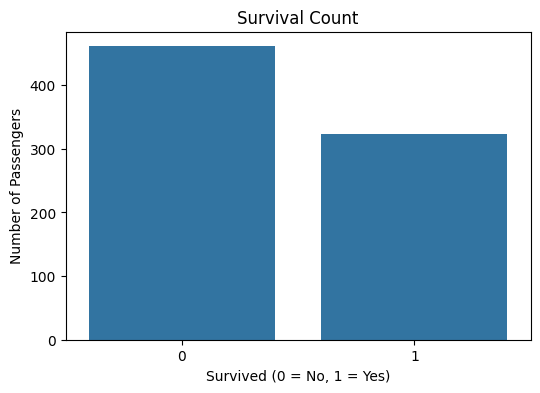

In [24]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="survived")

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

In [25]:
print("Survival by Gender:")
print(pd.crosstab(df["sex"], df["survived"]))

Survival by Gender:
survived    0    1
sex               
female     76  217
male      385  106


In [26]:
print("Survival Percentage by Gender:")

gender_survival = df.groupby("sex")["survived"].mean() * 100

print(gender_survival)

Survival Percentage by Gender:
sex
female    74.061433
male      21.588595
Name: survived, dtype: float64


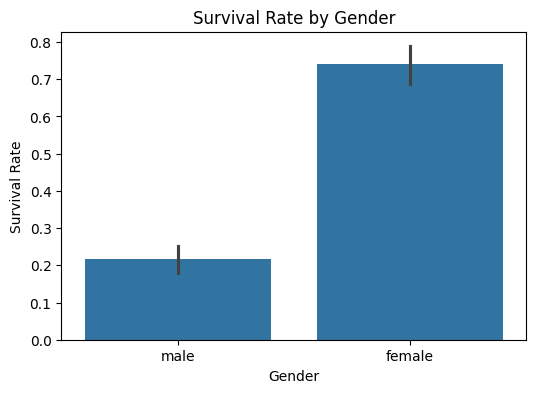

In [27]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

In [28]:
print("Survival by Passenger Class:")

class_survival = pd.crosstab(df["pclass"], df["survived"])

print(class_survival)

Survival by Passenger Class:
survived    0    1
pclass            
1          79  135
2          81   84
3         301  104


In [29]:
print("Survival Percentage by Passenger Class:")

class_survival_rate = df.groupby("pclass")["survived"].mean() * 100

print(class_survival_rate)

Survival Percentage by Passenger Class:
pclass
1    63.084112
2    50.909091
3    25.679012
Name: survived, dtype: float64


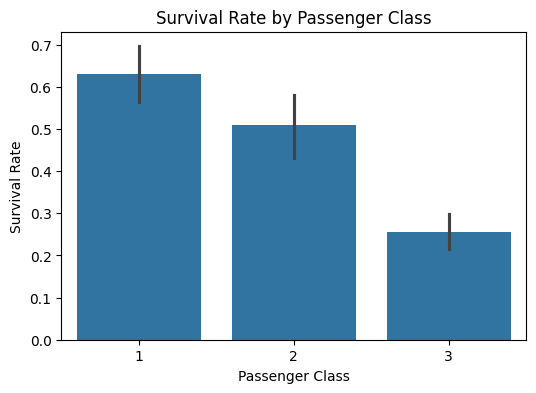

In [30]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

In [31]:
print("Age Statistics:")

print("Minimum Age:", df["age"].min())
print("Maximum Age:", df["age"].max())
print("Average Age:", df["age"].mean())
print("Median Age:", df["age"].median())

Age Statistics:
Minimum Age: 0.42
Maximum Age: 80.0
Average Age: 29.650408163265304
Median Age: 28.25


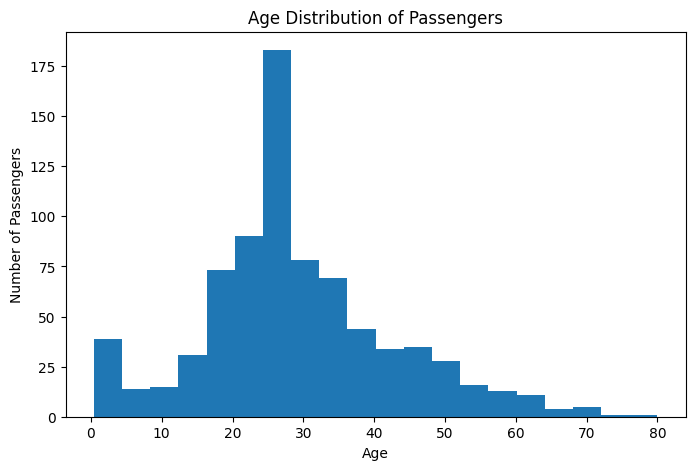

In [32]:
plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [33]:
print("Fare Statistics:")

print("Minimum Fare:", df["fare"].min())
print("Maximum Fare:", df["fare"].max())
print("Average Fare:", df["fare"].mean())
print("Median Fare:", df["fare"].median())

Fare Statistics:
Minimum Fare: 0.0
Maximum Fare: 512.3292
Average Fare: 34.71173966836735
Median Fare: 15.9


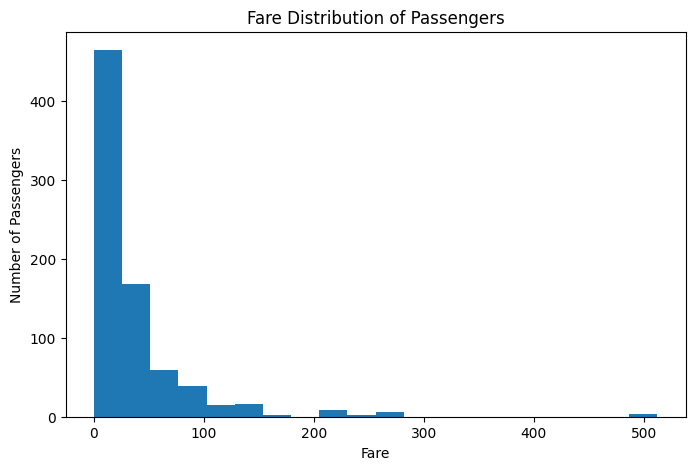

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(df["fare"], bins=20)

plt.title("Fare Distribution of Passengers")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

In [35]:
print("Survival by Embarkation Port:")

embarkation_survival = pd.crosstab(
    df["embarked"],
    df["survived"]
)

print(embarkation_survival)

Survival by Embarkation Port:
survived    0    1
embarked          
C          65   90
Q          39   20
S         357  213


In [36]:
print("Survival Percentage by Embarkation Port:")

embarkation_survival_rate = df.groupby("embarked")["survived"].mean() * 100

print(embarkation_survival_rate)

Survival Percentage by Embarkation Port:
embarked
C    58.064516
Q    33.898305
S    37.368421
Name: survived, dtype: float64


In [37]:
print("Survival by Travel Status:")

alone_survival = pd.crosstab(
    df["alone"],
    df["survived"]
)

print(alone_survival)

Survival by Travel Status:
survived    0    1
alone             
False     165  173
True      296  150


In [38]:
print("Survival Percentage by Travel Status:")

alone_survival_rate = df.groupby("alone")["survived"].mean() * 100

print(alone_survival_rate)

Survival Percentage by Travel Status:
alone
False    51.183432
True     33.632287
Name: survived, dtype: float64


In [39]:
print("Correlation Matrix:")

correlation = df.corr(numeric_only=True)

display(correlation)

Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.332658,-0.079184,-0.036589,0.070307,0.246769,-0.528502,-0.176595
pclass,-0.332658,1.000000,-0.342986,0.088014,0.040296,-0.549216,0.066816,0.109545
age,-0.079184,-0.342986,1.000000,-0.279431,-0.183777,0.091315,0.273607,0.191706
sibsp,-0.036589,0.088014,-0.279431,1.000000,0.381433,0.135147,-0.274521,-0.609502
parch,0.070307,0.040296,-0.183777,0.381433,1.000000,0.191942,-0.347186,-0.571087
fare,0.246769,-0.549216,0.091315,0.135147,0.191942,1.000000,-0.165209,-0.246619
adult_male,-0.528502,0.066816,0.273607,-0.274521,-0.347186,-0.165209,1.000000,0.387850
alone,-0.176595,0.109545,0.191706,-0.609502,-0.571087,-0.246619,0.387850,1.000000


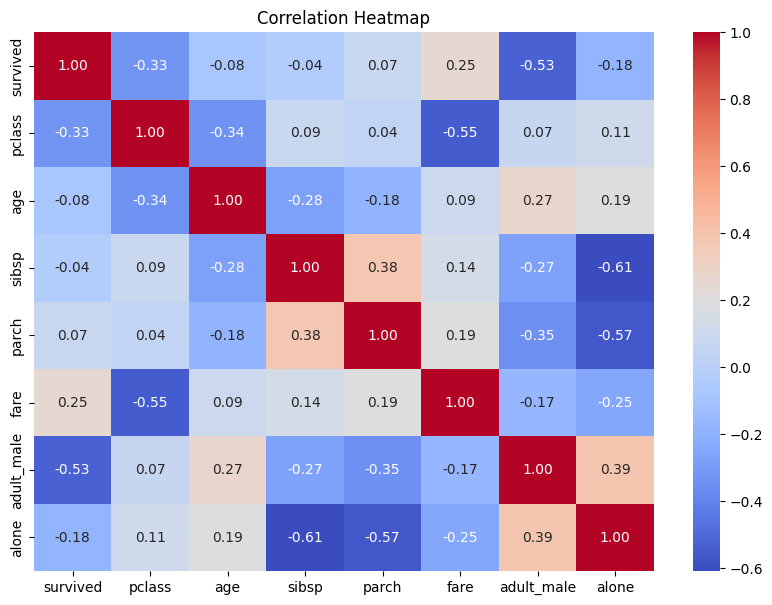

In [40]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [41]:
Q1_age = df["age"].quantile(0.25)
Q3_age = df["age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[
    (df["age"] < lower_age) |
    (df["age"] > upper_age)
]

print("Number of Age Outliers:", len(age_outliers))
print("Lower Bound:", lower_age)
print("Upper Bound:", upper_age)

Number of Age Outliers: 39
Lower Bound: 1.0
Upper Bound: 57.0


In [42]:
Q1_fare = df["fare"].quantile(0.25)
Q3_fare = df["fare"].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[
    (df["fare"] < lower_fare) |
    (df["fare"] > upper_fare)
]

print("Number of Fare Outliers:", len(fare_outliers))
print("Lower Bound:", lower_fare)
print("Upper Bound:", upper_fare)

Number of Fare Outliers: 102
Lower Bound: -31.039025
Upper Bound: 73.198375


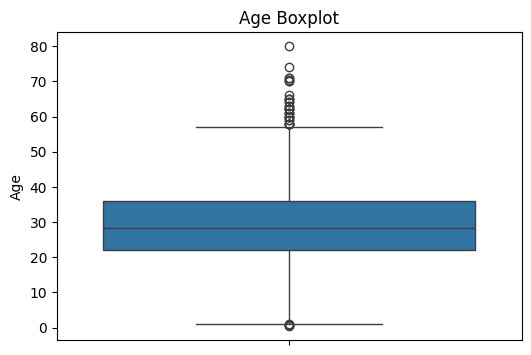

In [43]:
plt.figure(figsize=(6, 4))

sns.boxplot(y=df["age"])

plt.title("Age Boxplot")
plt.ylabel("Age")

plt.show()

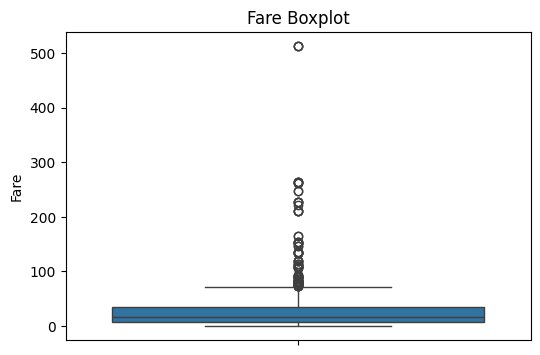

In [44]:
plt.figure(figsize=(6, 4))

sns.boxplot(y=df["fare"])

plt.title("Fare Boxplot")
plt.ylabel("Fare")

plt.show()

In [45]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

print("Survival Rate by Age Group:")
age_group_survival = df.groupby("age_group", observed=False)["survived"].mean() * 100
print(age_group_survival)

Survival Rate by Age Group:
age_group
Child          57.352941
Teen           44.776119
Young Adult    39.540230
Adult          40.104167
Senior         22.727273
Name: survived, dtype: float64


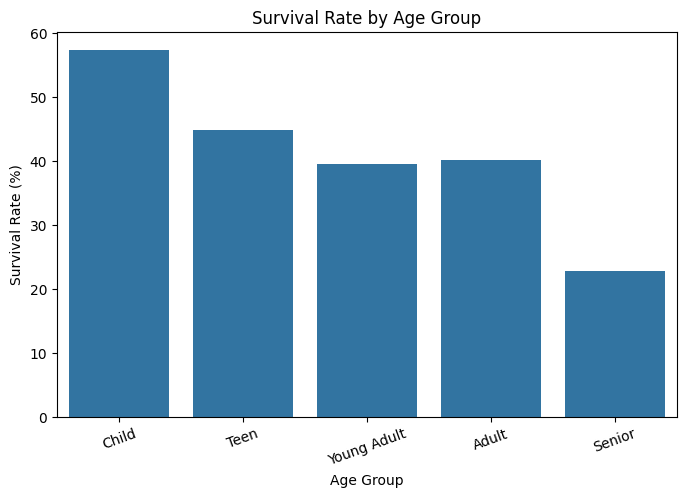

In [46]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_group_survival.index,
    y=age_group_survival.values
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=20)

plt.show()

In [47]:
df["family_size"] = df["sibsp"] + df["parch"] + 1

print("Family Size Summary:")
print(df["family_size"].value_counts().sort_index())

Family Size Summary:
family_size
1     446
2     154
3     101
4      28
5      13
6      22
7      12
8       6
11      2
Name: count, dtype: int64


In [48]:
print("Survival Rate by Family Size:")

family_survival = df.groupby("family_size")["survived"].mean() * 100

print(family_survival)

Survival Rate by Family Size:
family_size
1     33.632287
2     55.194805
3     57.425743
4     71.428571
5     23.076923
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: survived, dtype: float64


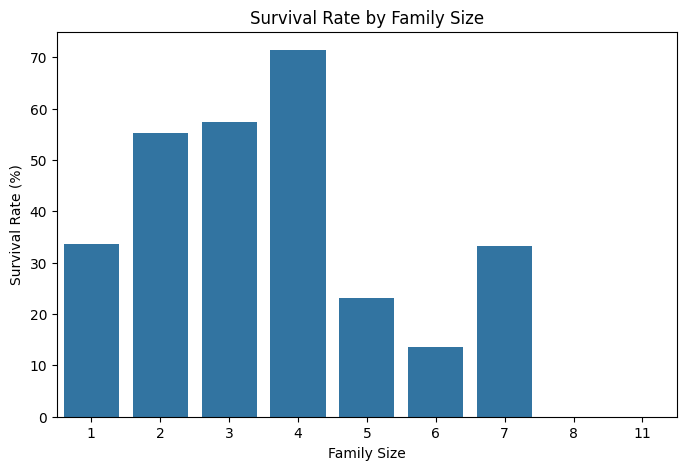

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=family_survival.index,
    y=family_survival.values
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

plt.show()

In [50]:
print("Survival Rate by Gender and Passenger Class:")

gender_class_survival = (
    df.groupby(["sex", "pclass"])["survived"]
    .mean() * 100
)

display(gender_class_survival)

Survival Rate by Gender and Passenger Class:


sex     pclass
female  1         96.774194
        2         91.780822
        3         47.244094
male    1         37.190083
        2         18.478261
        3         15.827338
Name: survived, dtype: float64

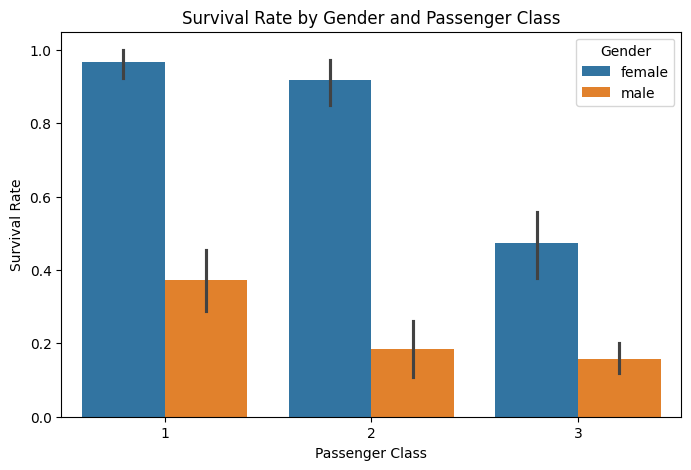

In [51]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Gender and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.legend(title="Gender")

plt.show()

In [52]:
summary = df[[
    "age",
    "fare",
    "sibsp",
    "parch",
    "family_size"
]].describe().T

display(summary)

,count,mean,std,min,25%,50%,75%,max
age,784.0,29.650408,13.734925,0.42,22.00,28.25,36.00000,80.0000
fare,784.0,34.711740,52.160151,0.00,8.05,15.90,34.10935,512.3292
sibsp,784.0,0.522959,0.986231,0.00,0.00,0.00,1.00000,8.0000
parch,784.0,0.415816,0.836922,0.00,0.00,0.00,1.00000,6.0000
family_size,784.0,1.938776,1.517485,1.00,1.00,1.00,2.00000,11.0000


In [53]:
print("KEY EDA INSIGHTS DATA")
print("-" * 40)

print("\n1. Overall Survival Rate:")
print(f"{df['survived'].mean() * 100:.2f}%")

print("\n2. Survival Rate by Gender:")
print((df.groupby("sex")["survived"].mean() * 100).round(2))

print("\n3. Survival Rate by Passenger Class:")
print((df.groupby("pclass")["survived"].mean() * 100).round(2))

print("\n4. Survival Rate by Embarkation Port:")
print((df.groupby("embarked")["survived"].mean() * 100).round(2))

print("\n5. Survival Rate by Travel Status:")
print((df.groupby("alone")["survived"].mean() * 100).round(2))

print("\n6. Survival Rate by Age Group:")
print((df.groupby("age_group", observed=False)["survived"].mean() * 100).round(2))

print("\n7. Survival Rate by Family Size:")
print((df.groupby("family_size")["survived"].mean() * 100).round(2))

KEY EDA INSIGHTS DATA
----------------------------------------

1. Overall Survival Rate:
41.20%

2. Survival Rate by Gender:
sex
female    74.06
male      21.59
Name: survived, dtype: float64

3. Survival Rate by Passenger Class:
pclass
1    63.08
2    50.91
3    25.68
Name: survived, dtype: float64

4. Survival Rate by Embarkation Port:
embarked
C    58.06
Q    33.90
S    37.37
Name: survived, dtype: float64

5. Survival Rate by Travel Status:
alone
False    51.18
True     33.63
Name: survived, dtype: float64

6. Survival Rate by Age Group:
age_group
Child          57.35
Teen           44.78
Young Adult    39.54
Adult          40.10
Senior         22.73
Name: survived, dtype: float64

7. Survival Rate by Family Size:
family_size
1     33.63
2     55.19
3     57.43
4     71.43
5     23.08
6     13.64
7     33.33
8      0.00
11     0.00
Name: survived, dtype: float64


In [55]:
print("FINAL DATASET SHAPE:", df.shape)
print("FINAL COLUMNS:")
print(df.columns.tolist())

FINAL DATASET SHAPE: (784, 17)
FINAL COLUMNS:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'age_group', 'family_size']


In [54]:
print("EDA CONCLUSION")
print("=" * 50)

print("""
The exploratory data analysis of the Titanic dataset revealed several
important patterns in passenger survival.

1. Survival rates differed significantly between male and female passengers.
2. Passenger class had a clear relationship with survival rates.
3. Age groups showed different survival patterns.
4. Family size and travel status were associated with survival.
5. Fare distribution contained high-value observations and potential outliers.
6. Age distribution also contained some potential outliers.
7. The correlation analysis showed relationships among numerical variables.

Overall, the analysis shows that passenger characteristics such as
gender, passenger class, age, family size, and fare were useful factors
for understanding survival patterns in the Titanic dataset.
""")

EDA CONCLUSION

The exploratory data analysis of the Titanic dataset revealed several
important patterns in passenger survival.

1. Survival rates differed significantly between male and female passengers.
2. Passenger class had a clear relationship with survival rates.
3. Age groups showed different survival patterns.
4. Family size and travel status were associated with survival.
5. Fare distribution contained high-value observations and potential outliers.
6. Age distribution also contained some potential outliers.
7. The correlation analysis showed relationships among numerical variables.

Overall, the analysis shows that passenger characteristics such as
gender, passenger class, age, family size, and fare were useful factors
for understanding survival patterns in the Titanic dataset.

